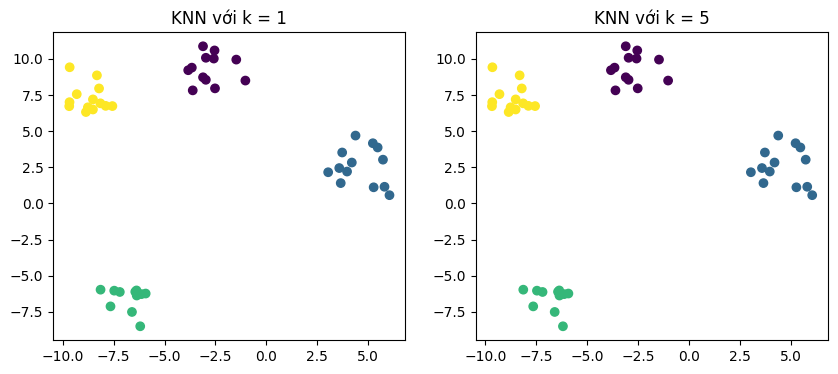

Best k: {'n_neighbors': np.int64(1)}
KNN tự cài đặt dự đoán: [1]


In [1]:
# =========================
# IMPORT THƯ VIỆN
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# =========================
# TẠO DỮ LIỆU
# =========================
X, y = make_blobs(n_samples=200, centers=4, random_state=42)

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# =========================
# 1. K-NN DÙNG THƯ VIỆN
# =========================

# k = 1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred1 = knn1.predict(X_test)

# k = 5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred5 = knn5.predict(X_test)

# Vẽ kết quả
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred1)
plt.title("KNN với k = 1")

plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred5)
plt.title("KNN với k = 5")

plt.show()

# =========================
# 2. TÌM k TỐI ƯU
# =========================
params = {'n_neighbors': np.arange(1, 10)}

grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X, y)

print("Best k:", grid.best_params_)

# =========================
# 3. K-NN TỰ CÀI ĐẶT
# =========================

def KNN(X_train, X_test, y_train, k):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]

    distances = np.zeros((num_test, num_train))

    # Tính khoảng cách
    for i in range(num_test):
        for j in range(num_train):
            distances[i,j] = np.sqrt(np.sum((X_test[i] - X_train[j])**2))

    results = []

    # Dự đoán
    for i in range(num_test):
        sorted_idx = np.argsort(distances[i])[:k]
        nearest_labels = y_train[sorted_idx]

        values, counts = np.unique(nearest_labels, return_counts=True)
        results.append(values[np.argmax(counts)])

    return np.array(results)

# TEST KNN tự viết
X_test_sample = np.array([[1, 3]])
result = KNN(X_train, X_test_sample, y_train, 3)

print("KNN tự cài đặt dự đoán:", result)